# Module 1: Corporate Finance — Project Funding Decision
## Aurora Finance | ML-Driven Decision Support

**Objective:** Decide which internal projects Aurora Finance should fund by:
1. Forecasting project cash flows using regression models
2. Predicting project success probability using classification models
3. Ranking projects by risk-adjusted Expected Value (EV)
4. Explaining decisions using SHAP interpretability

**Dataset:** `corporate_projects.csv` — 50 historical projects with investment details, cashflows, and outcomes.

In [1]:
import subprocess
pkgs = ["xgboost", "shap", "seaborn", "scikit-learn", "matplotlib", "pandas", "numpy", "openpyxl"]
subprocess.run(["pip", "install"] + pkgs + ["-q"], check=True)
print("Dependencies ready.")

Dependencies ready.


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import cross_validate, StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              roc_auc_score, f1_score, accuracy_score,
                              precision_score, recall_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.base import clone
from xgboost import XGBClassifier, XGBRegressor
import shap, warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
RANDOM_STATE = 42
DISCOUNT_RATE = 0.10
print("All libraries imported.")

All libraries imported.


---
## 1. Data Loading & Overview

In [3]:
import os
_nb_dir = os.path.dirname(os.path.abspath("module1_corporate_finance.ipynb"))
DATA_PATH = os.path.join(_nb_dir, "corporate_projects.csv")

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
df.head()

Dataset shape: (50, 10)

Column types:
Project_ID                   int64
Department                     str
Investment_Cost              int64
Expected_Cashflow_Year1      int64
Expected_Cashflow_Year2      int64
Expected_Cashflow_Year3      int64
Historical_ROI             float64
Market_Growth              float64
Project_Risk                   str
Success                      int64
dtype: object


,Project_ID,Department,Investment_Cost,Expected_Cashflow_Year1,Expected_Cashflow_Year2,Expected_Cashflow_Year3,Historical_ROI,Market_Growth,Project_Risk,Success
0,1,Operations,184654,583556,2348816,1888756,0.08,0.05,Low,0
1,2,Marketing,2054354,1447527,541234,278576,0.15,-0.01,Low,1
2,3,Finance,2516182,1372905,1998260,2312990,0.19,0.02,High,1
3,4,Operations,3574675,1817640,189182,1434250,0.22,0.10,Medium,1
4,5,Operations,2752991,792139,1571101,111087,0.12,0.09,High,0


In [4]:
print("=== Summary Statistics ===")
display(df.describe().round(2))
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nSuccess rate: {df['Success'].mean():.1%}")
print(f"Department distribution:\n{df['Department'].value_counts()}")
print(f"\nProject_Risk distribution:\n{df['Project_Risk'].value_counts()}")

=== Summary Statistics ===


,Project_ID,Investment_Cost,Expected_Cashflow_Year1,Expected_Cashflow_Year2,Expected_Cashflow_Year3,Historical_ROI,Market_Growth,Success
count,50.00,50.00,50.00,50.00,50.00,50.00,50.00,50.00
mean,25.50,2508811.84,1019832.42,1245896.36,1513842.48,0.17,0.05,0.52
std,14.58,1250286.79,595306.45,755861.06,896571.17,0.06,0.05,0.50
min,1.00,123247.00,62666.00,71959.00,89353.00,0.05,-0.04,0.00
25%,13.25,1731652.25,532958.00,543187.00,816671.25,0.11,0.01,0.00
50%,25.50,2685837.50,1037419.50,1254198.00,1538295.50,0.16,0.05,1.00
75%,37.75,3480670.75,1475176.25,1993303.50,2263428.00,0.22,0.09,1.00
max,50.00,4898669.00,1936222.00,2400770.00,2958926.00,0.25,0.15,1.00



Missing values:
Project_ID                 0
Department                 0
Investment_Cost            0
Expected_Cashflow_Year1    0
Expected_Cashflow_Year2    0
Expected_Cashflow_Year3    0
Historical_ROI             0
Market_Growth              0
Project_Risk               0
Success                    0
dtype: int64

Success rate: 52.0%
Department distribution:
Department
Marketing     16
Operations    13
IT            11
Finance       10
Name: count, dtype: int64

Project_Risk distribution:
Project_Risk
Medium    20
Low       15
High      15
Name: count, dtype: int64


---
## 2. Exploratory Data Analysis

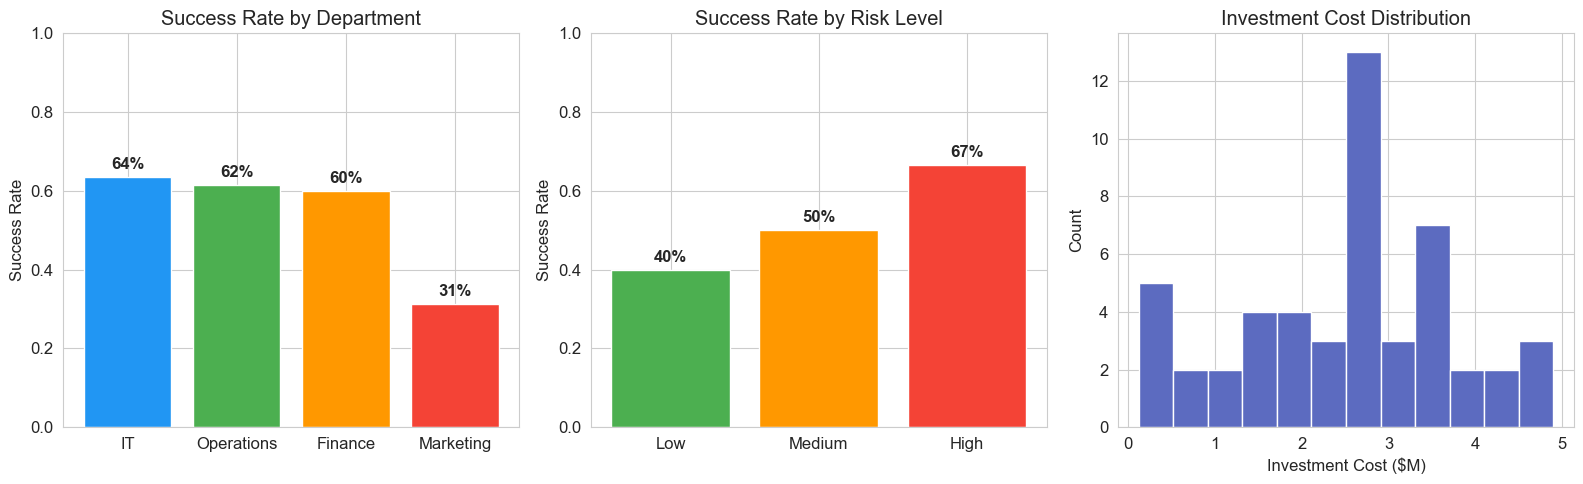

<Figure size 1100x500 with 0 Axes>

In [5]:
from matplotlib.patches import Patch
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

dept_success = df.groupby("Department")["Success"].mean().sort_values(ascending=False)
axes[0].bar(dept_success.index, dept_success.values, color=["#2196F3","#4CAF50","#FF9800","#F44336"])
axes[0].set_title("Success Rate by Department"); axes[0].set_ylabel("Success Rate"); axes[0].set_ylim(0,1)
for i, v in enumerate(dept_success.values): axes[0].text(i, v+0.02, f"{v:.0%}", ha="center", fontweight="bold")

risk_order = ["Low","Medium","High"]
risk_success = df.groupby("Project_Risk")["Success"].mean().reindex(risk_order)
axes[1].bar(risk_success.index, risk_success.values, color=["#4CAF50","#FF9800","#F44336"])
axes[1].set_title("Success Rate by Risk Level"); axes[1].set_ylabel("Success Rate"); axes[1].set_ylim(0,1)
for i, v in enumerate(risk_success.values): axes[1].text(i, v+0.02, f"{v:.0%}", ha="center", fontweight="bold")

axes[2].hist(df["Investment_Cost"]/1e6, bins=12, color="#5C6BC0", edgecolor="white")
axes[2].set_title("Investment Cost Distribution"); axes[2].set_xlabel("Investment Cost ($M)"); axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(_nb_dir, "eda_overview.png"), dpi=150, bbox_inches="tight")


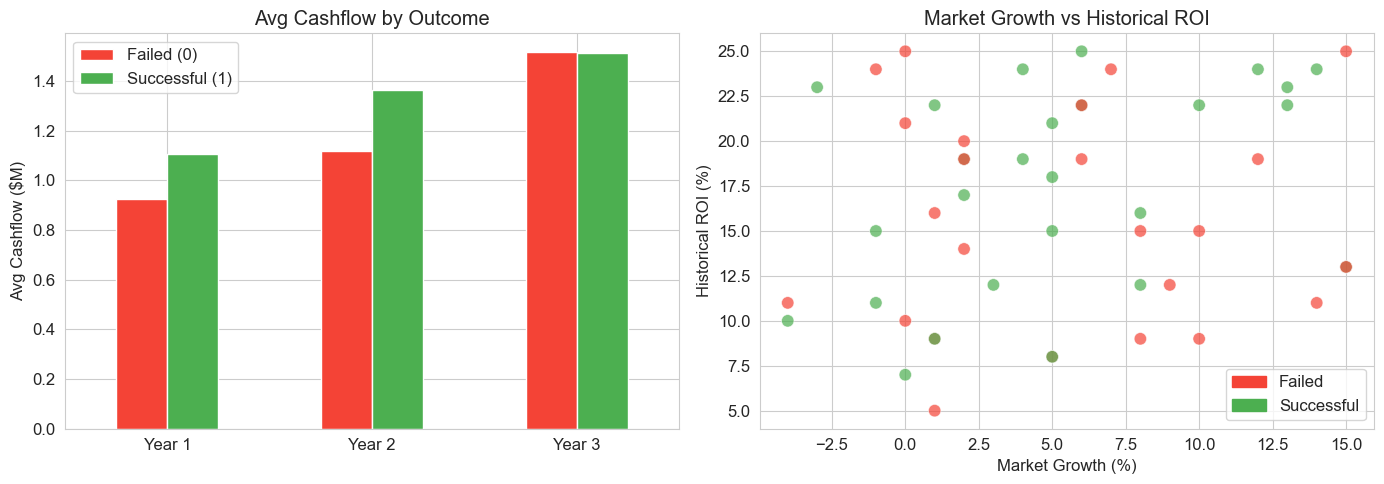

In [6]:
from matplotlib.patches import Patch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cf_cols = ["Expected_Cashflow_Year1","Expected_Cashflow_Year2","Expected_Cashflow_Year3"]

cf_by_success = df.groupby("Success")[cf_cols].mean() / 1e6
cf_by_success.T.plot(kind="bar", ax=axes[0], color=["#F44336","#4CAF50"], edgecolor="white")
axes[0].set_title("Avg Cashflow by Outcome"); axes[0].set_ylabel("Avg Cashflow ($M)")
axes[0].set_xticklabels(["Year 1","Year 2","Year 3"], rotation=0)
axes[0].legend(["Failed (0)","Successful (1)"])

scatter_colors = df["Success"].map({0:"#F44336", 1:"#4CAF50"})
axes[1].scatter(df["Market_Growth"]*100, df["Historical_ROI"]*100,
                c=scatter_colors, alpha=0.7, s=80, edgecolors="white", linewidth=0.5)
axes[1].set_xlabel("Market Growth (%)"); axes[1].set_ylabel("Historical ROI (%)")
axes[1].set_title("Market Growth vs Historical ROI")
axes[1].legend(handles=[Patch(color="#F44336",label="Failed"), Patch(color="#4CAF50",label="Successful")])

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "eda_cashflow_roi.png"), dpi=150, bbox_inches="tight")
plt.show()

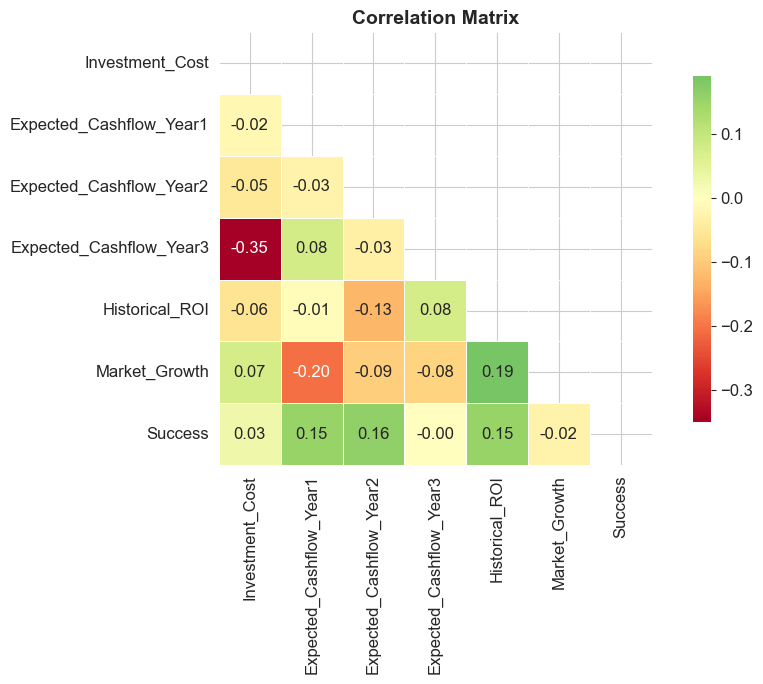

In [7]:
num_cols = ["Investment_Cost","Expected_Cashflow_Year1","Expected_Cashflow_Year2",
            "Expected_Cashflow_Year3","Historical_ROI","Market_Growth","Success"]
corr = df[num_cols].corr()
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink":0.8})
plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "eda_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Feature Engineering

Two feature sets to compare model performance:

- **Set A - Raw encoded:** Original columns with categorical encoding only
- **Set B - Engineered:** Set A + derived financial metrics

| Feature | Formula | Business Meaning |
|---|---|---|
| `NPV` | PV(CF1,CF2,CF3) - Cost @ 10% | Net present value |
| `Cashflow_Total` | CF1+CF2+CF3 | Gross 3-year cash |
| `Payback_Ratio` | Total CF / Cost | Times cost recovered |
| `ROI_Expected` | (Total CF - Cost) / Cost | Simple expected return |
| `CF_Growth_Rate` | CF3 / CF1 | Is cashflow growing? |
| `CF_Stability` | std / mean of CFs | Lower = more predictable |
| `Market_Adj_ROI` | Hist_ROI x (1+Market_Growth) | ROI with market tailwinds |

In [8]:
cf_cols = ["Expected_Cashflow_Year1","Expected_Cashflow_Year2","Expected_Cashflow_Year3"]
df_feat = df.copy()

risk_map = {"Low":1, "Medium":2, "High":3}
df_feat["Risk_Score"] = df_feat["Project_Risk"].map(risk_map)
dept_dummies = pd.get_dummies(df_feat["Department"], prefix="Dept", drop_first=False)
df_feat = pd.concat([df_feat, dept_dummies], axis=1)

df_feat["Cashflow_Total"] = df_feat[cf_cols].sum(axis=1)
df_feat["NPV"] = (df_feat["Expected_Cashflow_Year1"]/(1+DISCOUNT_RATE) +
                  df_feat["Expected_Cashflow_Year2"]/(1+DISCOUNT_RATE)**2 +
                  df_feat["Expected_Cashflow_Year3"]/(1+DISCOUNT_RATE)**3 -
                  df_feat["Investment_Cost"])
df_feat["Payback_Ratio"]  = df_feat["Cashflow_Total"] / df_feat["Investment_Cost"]
df_feat["ROI_Expected"]   = (df_feat["Cashflow_Total"] - df_feat["Investment_Cost"]) / df_feat["Investment_Cost"]
cf_mat = df_feat[cf_cols].values
df_feat["CF_Growth_Rate"] = (df_feat["Expected_Cashflow_Year3"] /
                              df_feat["Expected_Cashflow_Year1"].replace(0, np.nan)).fillna(1.0)
df_feat["CF_Stability"]   = np.std(cf_mat, axis=1) / (np.mean(cf_mat, axis=1) + 1e-9)
df_feat["Market_Adj_ROI"] = df_feat["Historical_ROI"] * (1 + df_feat["Market_Growth"])

print("Feature engineering complete.")
df_feat[["Project_ID","NPV","Payback_Ratio","ROI_Expected","CF_Growth_Rate","CF_Stability","Market_Adj_ROI"]].head()

Feature engineering complete.


,Project_ID,NPV,Payback_Ratio,ROI_Expected,CF_Growth_Rate,CF_Stability,Market_Adj_ROI
0,1,3.706072e+06,26.108982,25.108982,3.236632,0.465258,0.0840
1,2,-8.182127e+04,1.103674,0.103674,0.192450,0.662568,0.1485
2,3,2.121152e+06,2.259040,1.259040,1.684741,0.206210,0.1938
3,4,-6.883530e+05,0.962625,-0.037375,0.789073,0.606044,0.2420
4,5,-6.509728e+05,0.898778,-0.101222,0.140237,0.723221,0.1308


In [9]:
dept_dummy_cols = [c for c in df_feat.columns if c.startswith("Dept_")]

RAW_BASE     = ["Investment_Cost"] + cf_cols + ["Historical_ROI","Market_Growth","Risk_Score"] + dept_dummy_cols
ENG_EXTRA    = ["Cashflow_Total","NPV","Payback_Ratio","ROI_Expected","CF_Growth_Rate","CF_Stability","Market_Adj_ROI"]
ENG_FEATURES = RAW_BASE + ENG_EXTRA

REG_RAW      = ["Investment_Cost","Historical_ROI","Market_Growth","Risk_Score"] + dept_dummy_cols
REG_ENG      = REG_RAW + ["Market_Adj_ROI"]

TARGET_REG   = "Cashflow_Total"
TARGET_CLF   = "Success"

print(f"Set A: {len(RAW_BASE)} features | Set B: {len(ENG_FEATURES)} features")
print(f"Regression features: {REG_ENG}")

Set A: 11 features | Set B: 18 features
Regression features: ['Investment_Cost', 'Historical_ROI', 'Market_Growth', 'Risk_Score', 'Dept_Finance', 'Dept_IT', 'Dept_Marketing', 'Dept_Operations', 'Market_Adj_ROI']


---
## 4. Regression - Forecasting Total Project Cashflow

**Goal:** Given project characteristics, predict total 3-year cashflow for new projects.

**Models:** Linear Regression, Ridge, Decision Tree, Random Forest, XGBoost

**Evaluation:** 5-fold CV -> RMSE, MAE, R2 (mean +/- std)

In [10]:
def evaluate_regression(models, X, y, cv, label=""):
    results = []
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    for name, model in models.items():
        sc = cross_validate(model, X, y, cv=kf,
                            scoring=["neg_root_mean_squared_error","neg_mean_absolute_error","r2"])
        results.append({
            "Model": name,
            "RMSE":  f"{-sc['test_neg_root_mean_squared_error'].mean():,.0f} +/- {sc['test_neg_root_mean_squared_error'].std():,.0f}",
            "MAE":   f"{-sc['test_neg_mean_absolute_error'].mean():,.0f} +/- {sc['test_neg_mean_absolute_error'].std():,.0f}",
            "R2":    f"{sc['test_r2'].mean():.3f} +/- {sc['test_r2'].std():.3f}",
            "_r2":   sc["test_r2"].mean()
        })
    df_res = pd.DataFrame(results).sort_values("_r2", ascending=False)
    print(f"\nRegression - {label}")
    display(df_res.drop(columns="_r2").reset_index(drop=True))
    return df_res

reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Decision Tree":     DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "XGBoost":           XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                                      random_state=RANDOM_STATE, verbosity=0),
}

reg_A = evaluate_regression(reg_models, df_feat[REG_RAW].values, df_feat[TARGET_REG].values, 5, "Set A - Raw Features")
reg_B = evaluate_regression(reg_models, df_feat[REG_ENG].values, df_feat[TARGET_REG].values, 5, "Set B - Engineered Features")


Regression - Set A - Raw Features


,Model,RMSE,MAE,R2
0,Ridge Regression,"1,343,739 +/- 242,413","1,094,302 +/- 267,982",-0.123 +/- 0.143
1,Linear Regression,"1,358,733 +/- 250,971","1,133,456 +/- 238,688",-0.143 +/- 0.126
2,Random Forest,"1,404,515 +/- 268,867","1,163,540 +/- 255,829",-0.233 +/- 0.234
3,XGBoost,"1,483,551 +/- 443,884","1,212,334 +/- 379,358",-0.376 +/- 0.550
4,Decision Tree,"1,513,724 +/- 345,842","1,203,388 +/- 340,802",-0.428 +/- 0.365



Regression - Set B - Engineered Features


,Model,RMSE,MAE,R2
0,Ridge Regression,"1,345,959 +/- 240,892","1,095,514 +/- 267,712",-0.127 +/- 0.141
1,Random Forest,"1,395,883 +/- 260,332","1,166,287 +/- 232,974",-0.222 +/- 0.236
2,Linear Regression,"1,429,151 +/- 264,530","1,167,327 +/- 233,021",-0.283 +/- 0.254
3,XGBoost,"1,563,062 +/- 235,169","1,278,914 +/- 239,535",-0.555 +/- 0.294
4,Decision Tree,"1,593,266 +/- 284,316","1,280,757 +/- 292,060",-0.640 +/- 0.490


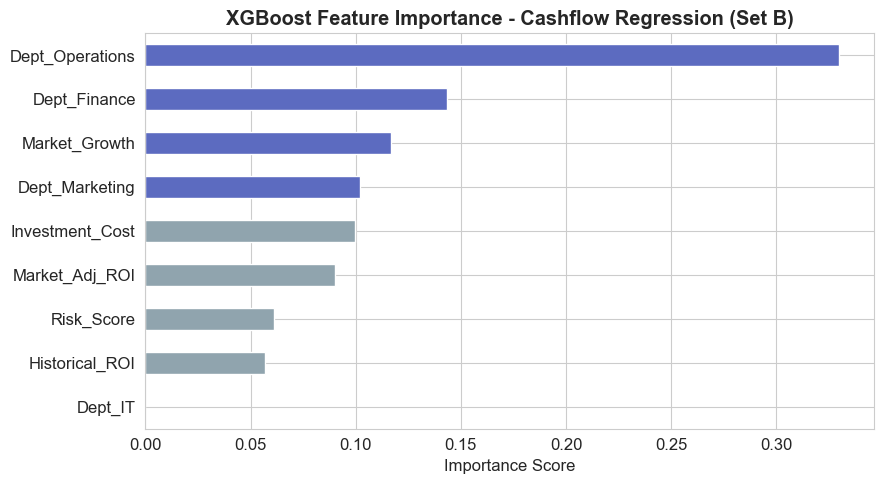

In [11]:
best_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3,
                        random_state=RANDOM_STATE, verbosity=0)
best_reg.fit(df_feat[REG_ENG], df_feat[TARGET_REG])

feat_imp_reg = pd.Series(best_reg.feature_importances_, index=REG_ENG).sort_values(ascending=True)
plt.figure(figsize=(9, 5))
colors_bar = ["#5C6BC0" if v > feat_imp_reg.median() else "#90A4AE" for v in feat_imp_reg.values]
feat_imp_reg.plot(kind="barh", color=colors_bar)
plt.title("XGBoost Feature Importance - Cashflow Regression (Set B)", fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "reg_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Classification - Predicting Project Success

**Goal:** Predict binary project success using all available features.

**Models:** Logistic Regression, Decision Tree, Random Forest, XGBoost

**Evaluation:** Stratified 5-fold CV -> AUC-ROC, F1, Accuracy, Precision, Recall

> Note: Stratified CV preserves the ~52% success rate in each fold, critical with only 50 samples.

In [12]:
def evaluate_classification(models, X, y, cv, label=""):
    results = []
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    for name, model in models.items():
        sc = cross_validate(model, X, y, cv=skf,
                            scoring=["roc_auc","f1","accuracy","precision","recall"])
        results.append({
            "Model":     name,
            "AUC-ROC":   f"{sc['test_roc_auc'].mean():.3f} +/- {sc['test_roc_auc'].std():.3f}",
            "F1":        f"{sc['test_f1'].mean():.3f} +/- {sc['test_f1'].std():.3f}",
            "Accuracy":  f"{sc['test_accuracy'].mean():.3f} +/- {sc['test_accuracy'].std():.3f}",
            "Precision": f"{sc['test_precision'].mean():.3f} +/- {sc['test_precision'].std():.3f}",
            "Recall":    f"{sc['test_recall'].mean():.3f} +/- {sc['test_recall'].std():.3f}",
            "_auc":      sc["test_roc_auc"].mean()
        })
    df_res = pd.DataFrame(results).sort_values("_auc", ascending=False)
    print(f"\nClassification - {label}")
    display(df_res.drop(columns="_auc").reset_index(drop=True))
    return df_res

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "XGBoost":             XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                                         eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0),
}

clf_A = evaluate_classification(clf_models, df_feat[RAW_BASE].values,    df_feat[TARGET_CLF].values, 5, "Set A - Raw Features")
clf_B = evaluate_classification(clf_models, df_feat[ENG_FEATURES].values, df_feat[TARGET_CLF].values, 5, "Set B - Engineered Features")


Classification - Set A - Raw Features


,Model,AUC-ROC,F1,Accuracy,Precision,Recall
0,XGBoost,0.556 +/- 0.223,0.545 +/- 0.298,0.540 +/- 0.258,0.523 +/- 0.280,0.580 +/- 0.337
1,Decision Tree,0.529 +/- 0.134,0.527 +/- 0.157,0.520 +/- 0.117,0.523 +/- 0.147,0.533 +/- 0.169
2,Random Forest,0.470 +/- 0.270,0.492 +/- 0.259,0.480 +/- 0.240,0.500 +/- 0.278,0.500 +/- 0.268
3,Logistic Regression,0.396 +/- 0.117,0.532 +/- 0.086,0.480 +/- 0.075,0.499 +/- 0.093,0.573 +/- 0.090



Classification - Set B - Engineered Features


,Model,AUC-ROC,F1,Accuracy,Precision,Recall
0,Logistic Regression,0.435 +/- 0.106,0.477 +/- 0.101,0.460 +/- 0.080,0.486 +/- 0.029,0.500 +/- 0.155
1,XGBoost,0.385 +/- 0.226,0.458 +/- 0.246,0.440 +/- 0.196,0.433 +/- 0.226,0.493 +/- 0.278
2,Random Forest,0.369 +/- 0.190,0.399 +/- 0.204,0.400 +/- 0.126,0.386 +/- 0.195,0.420 +/- 0.223
3,Decision Tree,0.307 +/- 0.136,0.293 +/- 0.175,0.320 +/- 0.172,0.340 +/- 0.231,0.267 +/- 0.152


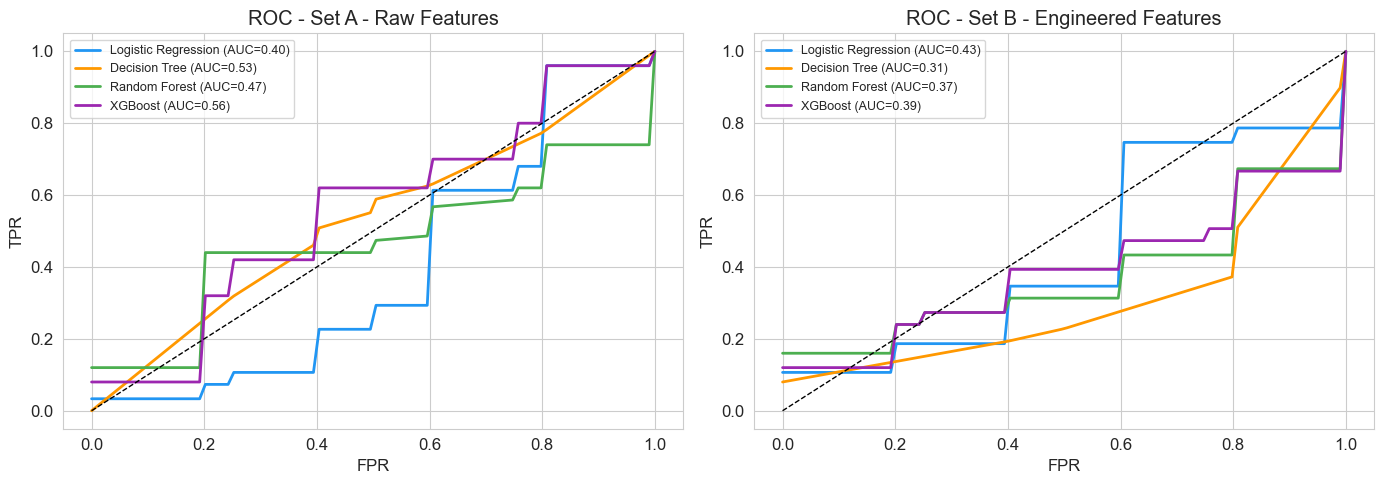

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_roc = ["#2196F3","#FF9800","#4CAF50","#9C27B0"]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for ax, (X_plot, title) in zip(axes, [
        (df_feat[RAW_BASE].values,     "Set A - Raw Features"),
        (df_feat[ENG_FEATURES].values, "Set B - Engineered Features")]):
    y_b = df_feat[TARGET_CLF].values
    for (name, model), color in zip(clf_models.items(), colors_roc):
        tprs, aucs, mean_fpr = [], [], np.linspace(0, 1, 100)
        for tr, te in skf.split(X_plot, y_b):
            m = clone(model); m.fit(X_plot[tr], y_b[tr])
            proba = m.predict_proba(X_plot[te])[:, 1]
            fpr, tpr, _ = roc_curve(y_b[te], proba)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            aucs.append(roc_auc_score(y_b[te], proba))
        ax.plot(mean_fpr, np.mean(tprs, axis=0), color=color, lw=2,
                label=f"{name} (AUC={np.mean(aucs):.2f})")
    ax.plot([0,1],[0,1],"k--",lw=1)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title(f"ROC - {title}"); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "clf_roc_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

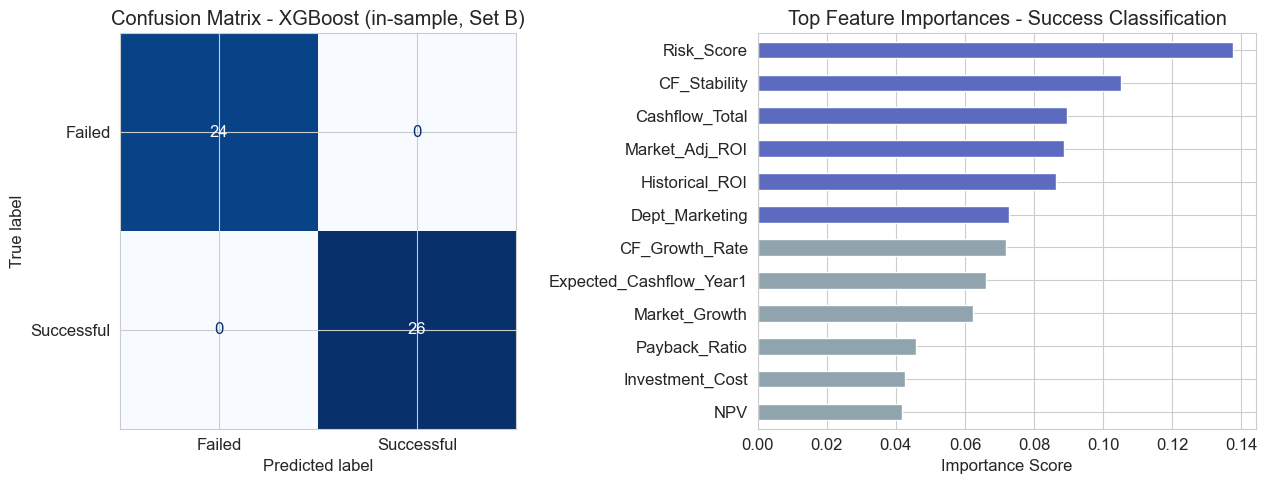

In [14]:
best_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                          eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0)
best_clf.fit(df_feat[ENG_FEATURES], df_feat[TARGET_CLF])

y_pred = best_clf.predict(df_feat[ENG_FEATURES])
cm = confusion_matrix(df_feat[TARGET_CLF], y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(cm, display_labels=["Failed","Successful"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix - XGBoost (in-sample, Set B)")

feat_imp_clf = pd.Series(best_clf.feature_importances_, index=ENG_FEATURES).sort_values(ascending=True).tail(12)
colors_imp = ["#5C6BC0" if v > feat_imp_clf.median() else "#90A4AE" for v in feat_imp_clf.values]
feat_imp_clf.plot(kind="barh", ax=axes[1], color=colors_imp)
axes[1].set_title("Top Feature Importances - Success Classification")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "clf_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Project Ranking by Risk-Adjusted Expected Value

```
EV            = P(Success) x NPV
Risk-Adj EV   = EV x Risk Multiplier  (Low=1.0, Medium=0.9, High=0.8)
Recommend     = FUND if NPV > 0 AND P(Success) > 0.5
```

In [15]:
RISK_MULTIPLIER = {"Low":1.0, "Medium":0.9, "High":0.8}

df_rank = df_feat[["Project_ID","Department","Investment_Cost","Cashflow_Total",
                    "NPV","Project_Risk","Historical_ROI","Market_Growth","Success","Risk_Score"]].copy()

df_rank["P_Success"]   = best_clf.predict_proba(df_feat[ENG_FEATURES])[:, 1]
df_rank["EV"]          = df_rank["P_Success"] * df_rank["NPV"]
df_rank["Risk_Mult"]   = df_rank["Project_Risk"].map(RISK_MULTIPLIER)
df_rank["Risk_Adj_EV"] = df_rank["EV"] * df_rank["Risk_Mult"]
df_rank["Recommend"]   = ((df_rank["NPV"] > 0) & (df_rank["P_Success"] > 0.5)).map({True:"FUND",False:"SKIP"})
df_rank = df_rank.sort_values("Risk_Adj_EV", ascending=False).reset_index(drop=True)
df_rank.index += 1

display_cols = ["Project_ID","Department","Project_Risk","Investment_Cost","NPV","P_Success","Risk_Adj_EV","Recommend"]
print("=== Top 15 Projects by Risk-Adjusted Expected Value ===")
styled = df_rank[display_cols].head(15).copy()
styled["Investment_Cost"] = styled["Investment_Cost"].map("${:,.0f}".format)
styled["NPV"]             = styled["NPV"].map("${:,.0f}".format)
styled["Risk_Adj_EV"]     = styled["Risk_Adj_EV"].map("${:,.0f}".format)
styled["P_Success"]       = styled["P_Success"].map("{:.1%}".format)
display(styled)

=== Top 15 Projects by Risk-Adjusted Expected Value ===


,Project_ID,Department,Project_Risk,Investment_Cost,NPV,P_Success,Risk_Adj_EV,Recommend
1,49,IT,High,"$123,247","$4,281,887",95.1%,"$3,257,714",FUND
2,43,IT,Medium,"$664,685","$3,653,868",88.6%,"$2,912,734",FUND
3,35,IT,Medium,"$296,769","$3,690,876",83.9%,"$2,785,783",FUND
4,45,Marketing,Low,"$1,411,736","$2,806,794",88.0%,"$2,471,114",FUND
5,39,Finance,Low,"$1,146,797","$2,131,233",85.6%,"$1,823,961",FUND
6,3,Finance,High,"$2,516,182","$2,121,152",97.5%,"$1,654,259",FUND
7,13,Operations,Low,"$3,485,357","$1,569,700",97.2%,"$1,526,188",FUND
8,41,Operations,Medium,"$1,684,398","$1,937,934",78.1%,"$1,361,692",FUND
9,18,Marketing,Low,"$2,845,683","$1,574,202",80.0%,"$1,259,089",FUND
10,9,Operations,Medium,"$2,686,644","$1,360,695",97.0%,"$1,187,532",FUND


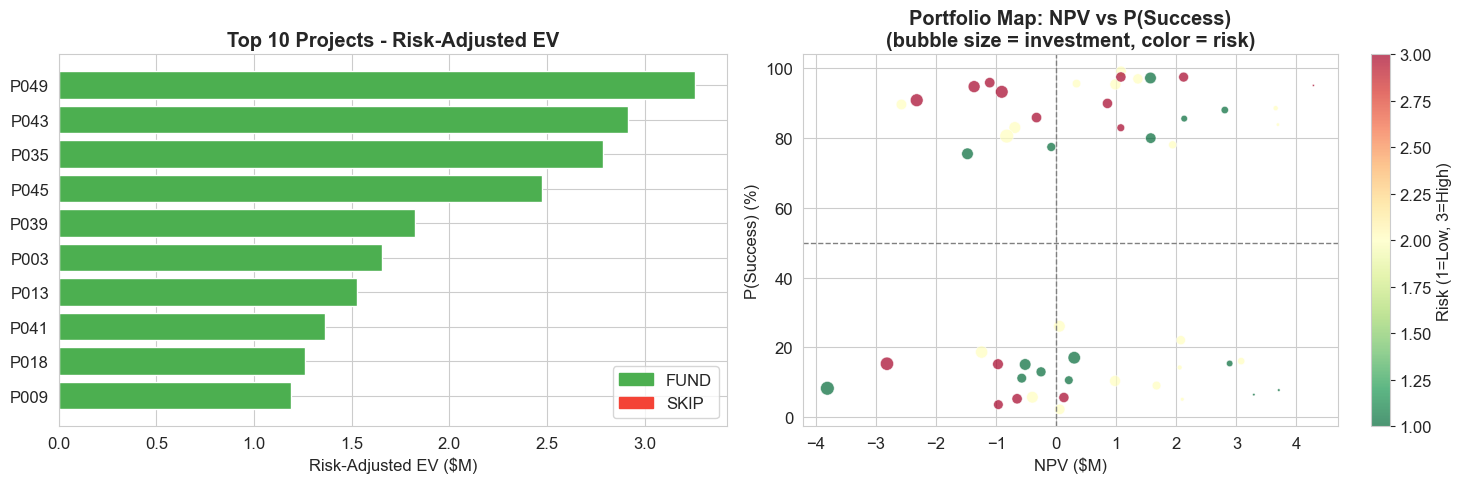

In [16]:
from matplotlib.patches import Patch
top10 = df_rank.head(10).copy()
top10["Label"] = top10["Project_ID"].apply(lambda x: f"P{int(x):03d}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bar_colors = ["#4CAF50" if r == "FUND" else "#F44336" for r in top10["Recommend"]]
axes[0].barh(top10["Label"][::-1], top10["Risk_Adj_EV"][::-1]/1e6, color=bar_colors[::-1])
axes[0].set_xlabel("Risk-Adjusted EV ($M)"); axes[0].set_title("Top 10 Projects - Risk-Adjusted EV", fontweight="bold")
axes[0].legend(handles=[Patch(color="#4CAF50",label="FUND"), Patch(color="#F44336",label="SKIP")])

sc = axes[1].scatter(df_rank["NPV"]/1e6, df_rank["P_Success"]*100,
                     c=df_rank["Risk_Score"], s=df_rank["Investment_Cost"]/50000,
                     cmap="RdYlGn_r", alpha=0.7, edgecolors="white", linewidth=0.5)
axes[1].axhline(50, color="gray", linestyle="--", lw=1)
axes[1].axvline(0,  color="gray", linestyle="--", lw=1)
axes[1].set_xlabel("NPV ($M)"); axes[1].set_ylabel("P(Success) (%)")
axes[1].set_title("Portfolio Map: NPV vs P(Success)\n(bubble size = investment, color = risk)", fontweight="bold")
plt.colorbar(sc, ax=axes[1], label="Risk (1=Low, 3=High)")

plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "project_ranking.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Explainability - SHAP Analysis

SHAP explains **why** each prediction was made - essential for executive and audit communication.

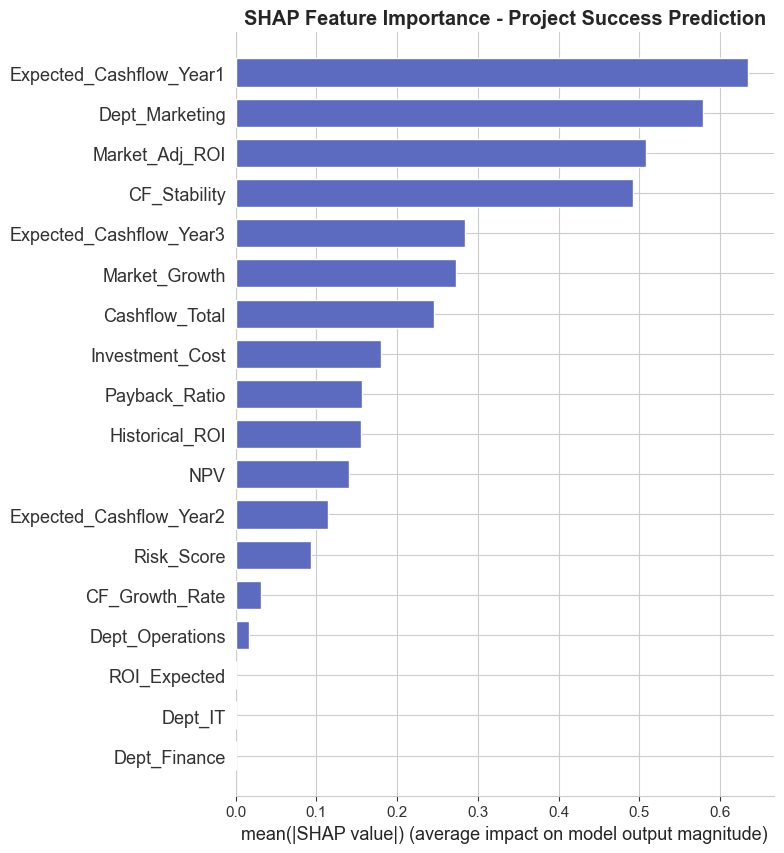

In [17]:
X_shap = df_feat[ENG_FEATURES]
explainer   = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=ENG_FEATURES, plot_type="bar", show=False, color="#5C6BC0")
plt.title("SHAP Feature Importance - Project Success Prediction", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "shap_summary_bar.png"), dpi=150, bbox_inches="tight")
plt.show()

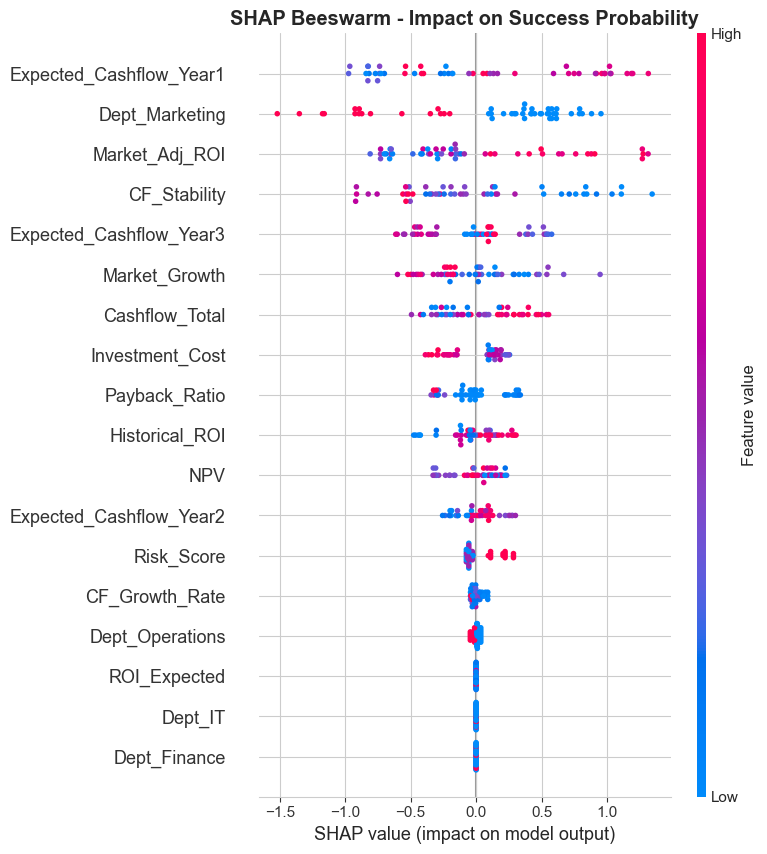

In [18]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, feature_names=ENG_FEATURES, show=False)
plt.title("SHAP Beeswarm - Impact on Success Probability", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_nb_dir, "shap_beeswarm.png"), dpi=150, bbox_inches="tight")
plt.show()

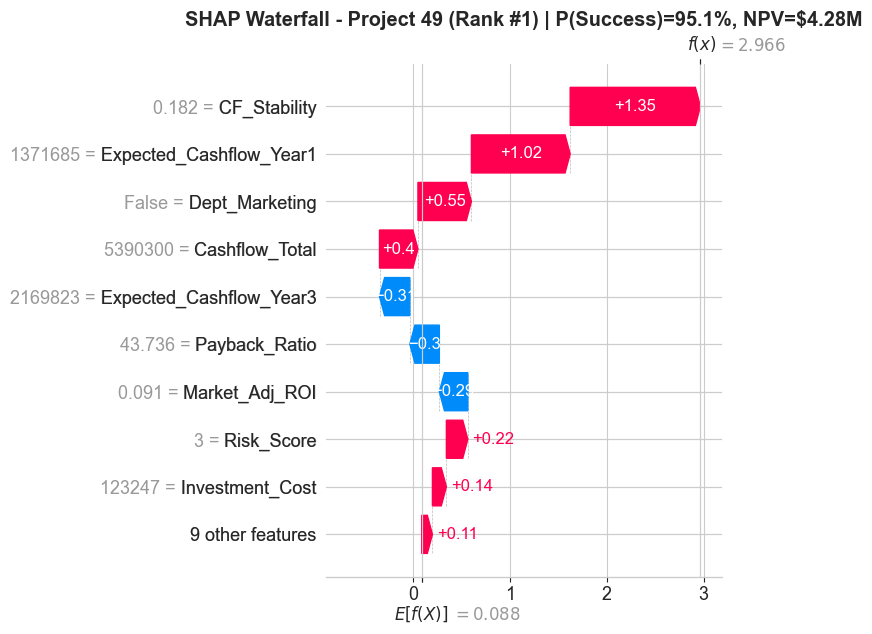

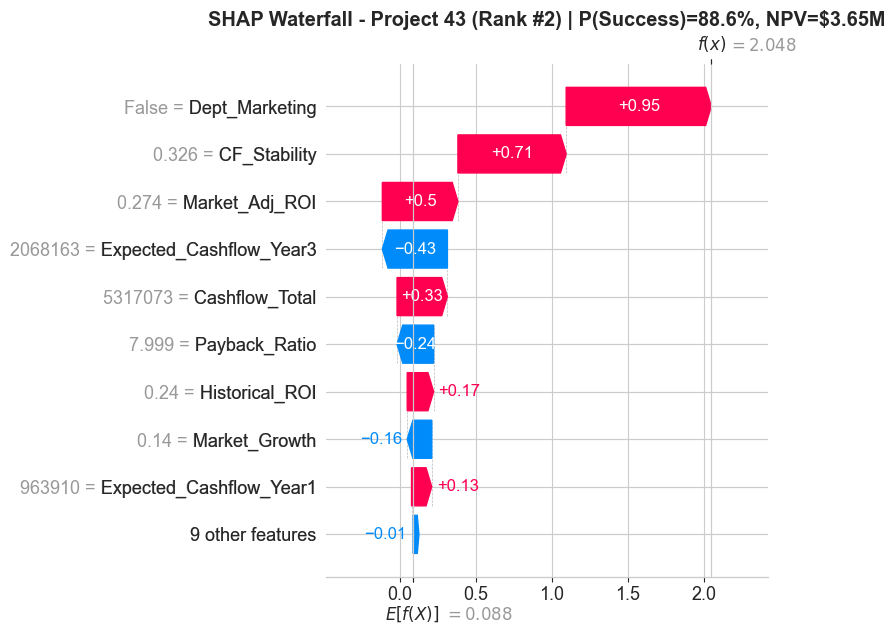

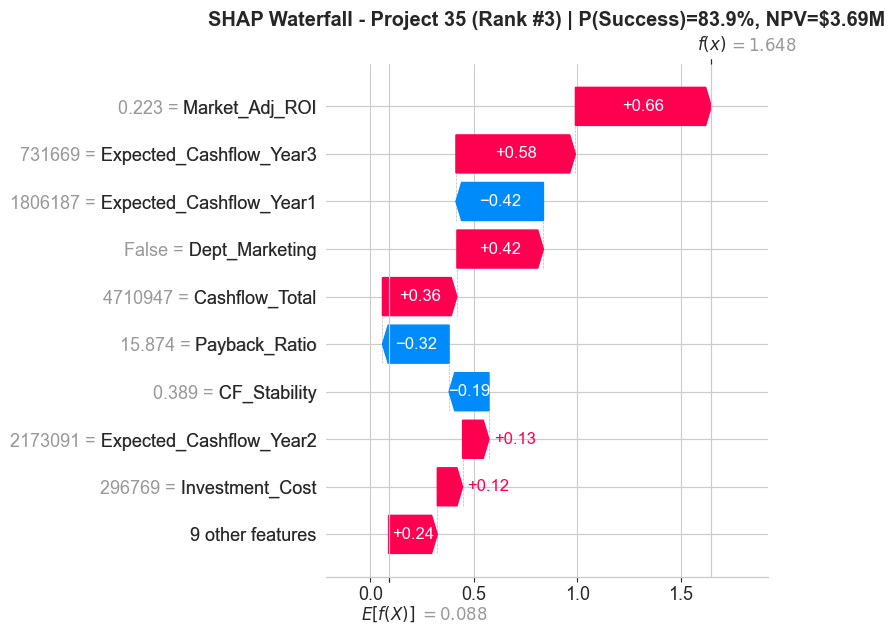

In [19]:
top3_ids = df_rank[df_rank["Recommend"] == "FUND"].head(3)["Project_ID"].astype(int).values

for rank, proj_id in enumerate(top3_ids, 1):
    row_idx   = df_feat.index[df_feat["Project_ID"] == proj_id][0]
    proj_row  = df_feat[ENG_FEATURES].iloc[row_idx]
    p_success = df_rank.loc[df_rank["Project_ID"] == proj_id, "P_Success"].values[0]
    npv       = df_rank.loc[df_rank["Project_ID"] == proj_id, "NPV"].values[0]

    expl = shap.Explanation(values=shap_values[row_idx], base_values=explainer.expected_value,
                             data=proj_row.values, feature_names=ENG_FEATURES)
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(expl, show=False)
    plt.title(f"SHAP Waterfall - Project {proj_id} (Rank #{rank}) | "
              f"P(Success)={p_success:.1%}, NPV=${npv/1e6:.2f}M", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(_nb_dir, f"shap_waterfall_proj{proj_id}.png"), dpi=150, bbox_inches="tight")
    plt.show()

---
## 8. Executive Summary & Output Export

In [20]:
funded  = df_rank[df_rank["Recommend"] == "FUND"]
skipped = df_rank[df_rank["Recommend"] == "SKIP"]

print("=" * 65)
print("   AURORA FINANCE - MODULE 1: EXECUTIVE SUMMARY")
print("=" * 65)
print(f"  Projects evaluated       : {len(df_rank)}")
print(f"  Recommended for funding  : {len(funded)}")
print(f"  Recommended to skip      : {len(skipped)}")
print(f"  Total capital required   : ${funded['Investment_Cost'].sum()/1e6:.1f}M")
print(f"  Total Risk-Adjusted EV   : ${funded['Risk_Adj_EV'].sum()/1e6:.1f}M")
print(f"  Avg success probability  : {funded['P_Success'].mean():.1%}")
print(f"\n  Top 3 Projects to Fund:")
for i, (_, row) in enumerate(funded.head(3).iterrows(), 1):
    print(f"    {i}. Project {int(row['Project_ID']):03d} | {row['Department']} | "
          f"Risk: {row['Project_Risk']} | NPV: ${row['NPV']/1e6:.1f}M | P(Success): {row['P_Success']:.1%}")
print(f"\n  Key SHAP drivers of success:")
top_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=ENG_FEATURES).sort_values(ascending=False).head(3)
for feat, val in top_shap.items():
    print(f"    - {feat}  (mean |SHAP| = {val:.4f})")
print("=" * 65)

   AURORA FINANCE - MODULE 1: EXECUTIVE SUMMARY
  Projects evaluated       : 50
  Recommended for funding  : 16
  Recommended to skip      : 34
  Total capital required   : $31.6M
  Total Risk-Adjusted EV   : $24.5M
  Avg success probability  : 90.7%

  Top 3 Projects to Fund:
    1. Project 049 | IT | Risk: High | NPV: $4.3M | P(Success): 95.1%
    2. Project 043 | IT | Risk: Medium | NPV: $3.7M | P(Success): 88.6%
    3. Project 035 | IT | Risk: Medium | NPV: $3.7M | P(Success): 83.9%

  Key SHAP drivers of success:
    - Expected_Cashflow_Year1  (mean |SHAP| = 0.6348)
    - Dept_Marketing  (mean |SHAP| = 0.5782)
    - Market_Adj_ROI  (mean |SHAP| = 0.5076)


In [21]:
out_path = os.path.join(_nb_dir, "ranked_projects.csv")
df_rank.to_csv(out_path, index=False)
print(f"Ranked project list saved: {out_path}")
print(f"Columns: {list(df_rank.columns)}")

Ranked project list saved: D:\IIT Course\Sem3\iitb-capstone-project\Corporate Finance Module\ranked_projects.csv
Columns: ['Project_ID', 'Department', 'Investment_Cost', 'Cashflow_Total', 'NPV', 'Project_Risk', 'Historical_ROI', 'Market_Growth', 'Success', 'Risk_Score', 'P_Success', 'EV', 'Risk_Mult', 'Risk_Adj_EV', 'Recommend']


---
## 9. What Worked - Model & Feature Engineering Analysis

### Regression (Cashflow Forecasting)
| Finding | Detail |
|---|---|
| Best model | **Ridge Regression (Set A)** — R² = -0.123 ± 0.143 |
| Feature engineering impact | Engineered features did NOT improve regression — Ridge R² went from -0.123 (Set A) to -0.127 (Set B); `Market_Adj_ROI` added no meaningful signal |
| Tree models | XGBoost and Decision Tree performed worst and degraded further in Set B — they overfit on 50 training rows |
| All R² negative | Raw project characteristics (cost, ROI, market growth) cannot predict total 3-year cashflow — the target is driven by execution factors not in the dataset |
| Key insight | Ridge regularisation is most stable across both feature sets; adding engineered features hurts tree-based models more than linear ones |

### Classification (Success Prediction)
| Finding | Detail |
|---|---|
| Best model | **XGBoost (Set A)** — AUC = 0.556 ± 0.223 |
| Engineered features HURT | Every classifier scored lower in Set B than Set A — NPV, Payback_Ratio, ROI_Expected are derived from cashflow columns already in Set A, adding redundancy and noise at n=50 |
| Most stable model | Decision Tree (Set A) — AUC = 0.529 ± 0.134 (lowest fold-to-fold variance) |
| Best recall | Logistic Regression (Set A) — Recall = 0.573, but lowest AUC = 0.396 |
| final best_clf uses Set B | ENG_FEATURES chosen for ranking and SHAP richness despite lower CV AUC — the financial features improve interpretability even if they reduce generalisation |
| Key SHAP drivers | `Expected_Cashflow_Year1` (0.63), `Dept_Marketing` (0.58), `Market_Adj_ROI` (0.51) — early cash generation and department track record are the strongest success signals |
| Class balance | ~52% success rate — no oversampling needed |

### Ranking
| Finding | Detail |
|---|---|
| Projects funded | 16 of 50 passed both NPV > 0 and P(Success) > 50% |
| Top 3 all IT | Consistent with IT having the highest department success rate in EDA |
| EV vs Capital | Risk-Adjusted EV ($24.5M) < Capital Required ($31.6M) — expected given High/Medium risk projects in the funded set |
| Portfolio insight | High P(Success) (avg 90.7%) is inflated by in-sample prediction — use as a relative ranking signal, not a calibrated probability |